In [1]:
import pandas as pd
import numpy as np
import openpyxl
import matplotlib.pyplot as plt
import seaborn as sns
df= pd.read_excel(r"C:\vs code programming\.vscode\NewCfile\Codebasics_ML\premium_project\premiums.xlsx")
df.shape

(50000, 13)

### EDA

In [292]:
df.columns

Index(['Age', 'Gender', 'Region', 'Marital_status', 'Number Of Dependants',
       'BMI_Category', 'Smoking_Status', 'Employment_Status', 'Income_Level',
       'Income_Lakhs', 'Medical History', 'Insurance_Plan',
       'Annual_Premium_Amount'],
      dtype='str')

In [293]:
df.columns= df.columns.str.replace(' ', '_').str.lower()
df.head(1)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053


## Remove NULL VALUES

In [294]:
df.isna().sum()
#here we dont have too many NA values so instead of using mean median or mode we can just drop them

age                       0
gender                    0
region                    0
marital_status            0
number_of_dependants      0
bmi_category              0
smoking_status           11
employment_status         2
income_level             13
income_lakhs              0
medical_history           0
insurance_plan            0
annual_premium_amount     0
dtype: int64

In [295]:
df.dropna(inplace=True)
df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
dtype: int64

### Remove duplicates


In [296]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [297]:
df.describe()
#outliers: age=365, min no. of dependencies= -3, max income= 930L

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,49976.000000,49976.000000,49976.000000,49976.000000
mean,34.591764,1.711842,23.021150,15766.810189
std,15.000378,1.498195,24.221794,8419.995271
min,18.000000,-3.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8607.750000
50%,31.000000,2.000000,17.000000,13928.000000
75%,45.000000,3.000000,31.000000,22273.500000
max,356.000000,5.000000,930.000000,43471.000000


### Fixing outliers


In [298]:
df[df.number_of_dependants<0]['number_of_dependants'].unique()

array([-3, -1])

In [299]:
df['number_of_dependants']= abs(df['number_of_dependants'])
#convert all dependants to its abs value

### Boxplot to find outliers


In [300]:
num_col = df.select_dtypes(['float64', 'int64']).columns
num_col

Index(['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount'], dtype='str')

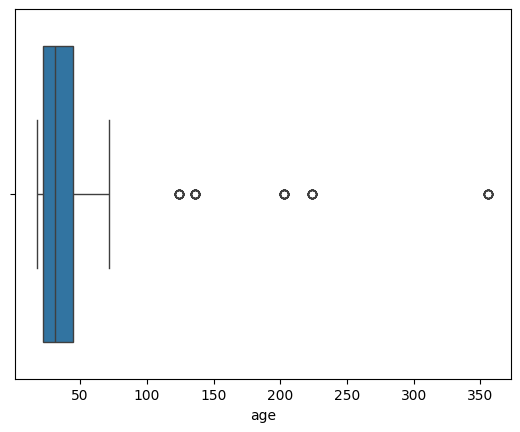

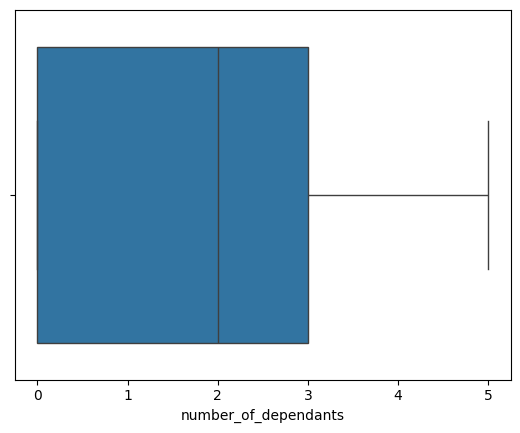

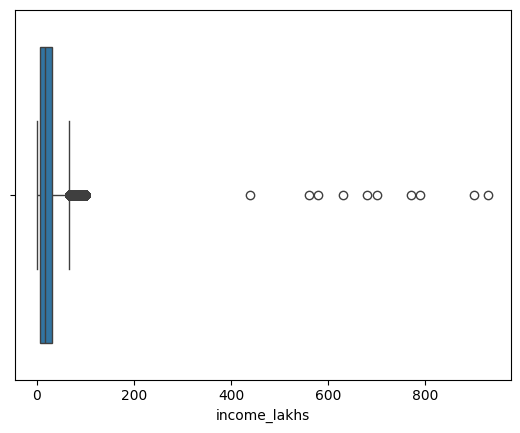

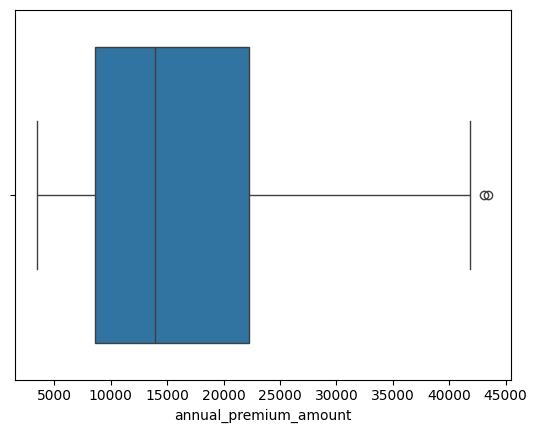

In [301]:
for i in num_col:
    sns.boxplot(x= df[i])
    plt.show()
#we see, age, income_lakhs and anual_premium has outliers
#we can leave them for anual_income as its valid

In [302]:
df[df.age>100]['age'].unique()

array([224, 124, 136, 203, 356])

In [303]:
df = df[df['age']<=100]
df[df.age>100]['age'].unique()

array([], dtype=int64)

<Axes: xlabel='income_lakhs', ylabel='Count'>

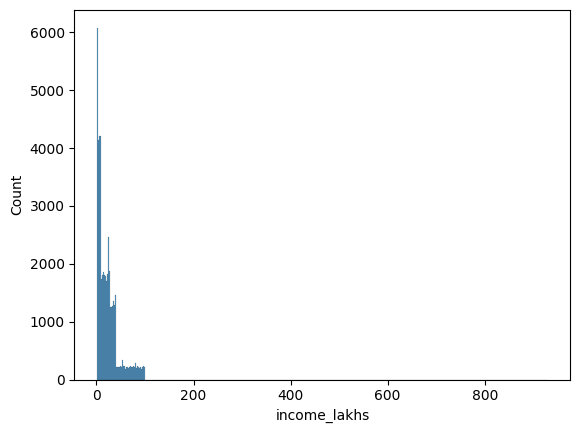

In [304]:
sns.histplot(x=df['income_lakhs'])

In [305]:
df.income_lakhs.quantile([0.25, 0.75])

0.25     7.0
0.75    31.0
Name: income_lakhs, dtype: float64

In [306]:
def get_iqr(col):
    q1 , q3 = col.quartile([0.25, 0.75])
    IQR= q3-q1
    lower_bound= q1 - 1.5*IQR
    upper_bound= q3 + 1.5*IQR
    return lower_bound, upper_bound

In [307]:
##we got upper bound as 67L but in india many people have income >=67L
threshold= df.income_lakhs.quantile(0.999)
threshold

np.float64(100.0)

In [308]:
df1= df[df.income_lakhs>threshold]
df1['income_lakhs'].shape
#only 10 has income more than 100L. so just dro them

(10,)

In [309]:
df1= df[df.income_lakhs<=threshold].copy()
df1.describe()
#now income is in a reasonable range

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,49908.000000,49908.000000,49908.000000,49908.000000
mean,34.401579,1.717640,22.889897,15765.739641
std,13.681604,1.492032,22.170699,8418.674061
min,18.000000,0.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8608.000000
50%,31.000000,2.000000,17.000000,13928.000000
75%,45.000000,3.000000,31.000000,22270.500000
max,72.000000,5.000000,100.000000,43471.000000


### distribution of numeric column( to understand skewness)

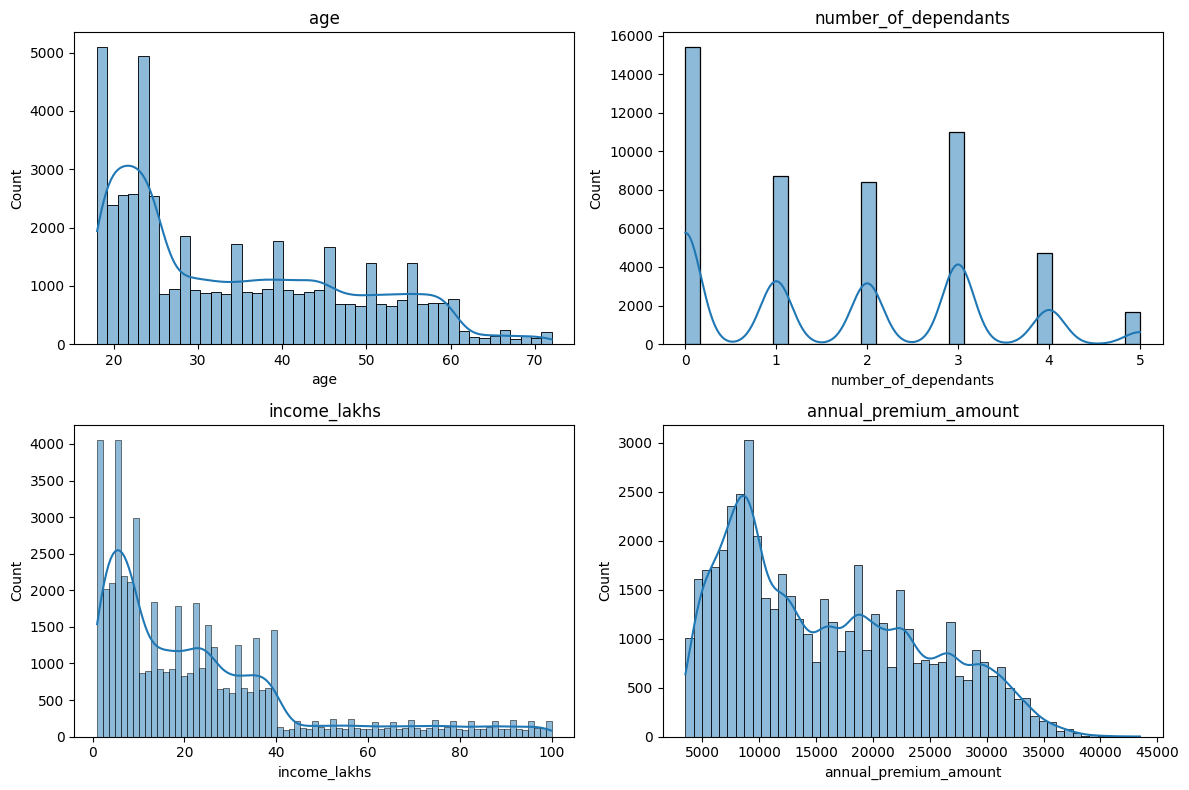

In [310]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes = axes.flatten()  # Convert 2D array of axes into 1D

for i, c in enumerate(num_col):
    sns.histplot(df1[c], kde=True, ax=axes[i])
    axes[i].set_title(c)

plt.tight_layout()
plt.show()
    
#income based columns are genearally right skewed

<Axes: xlabel='age', ylabel='annual_premium_amount'>

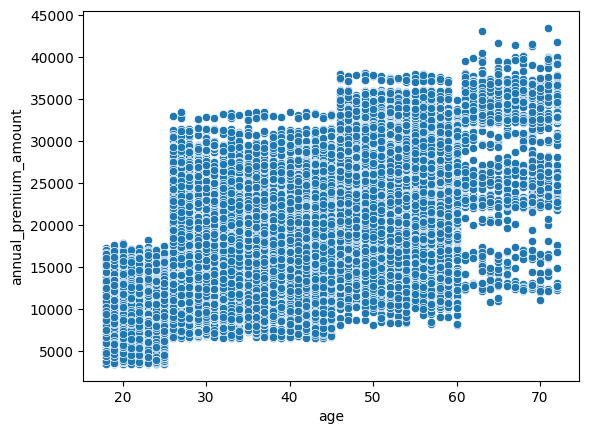

In [311]:
sns.scatterplot(df1, x='age', y='annual_premium_amount')
#the graph is messy but we see as age increases, premium increases

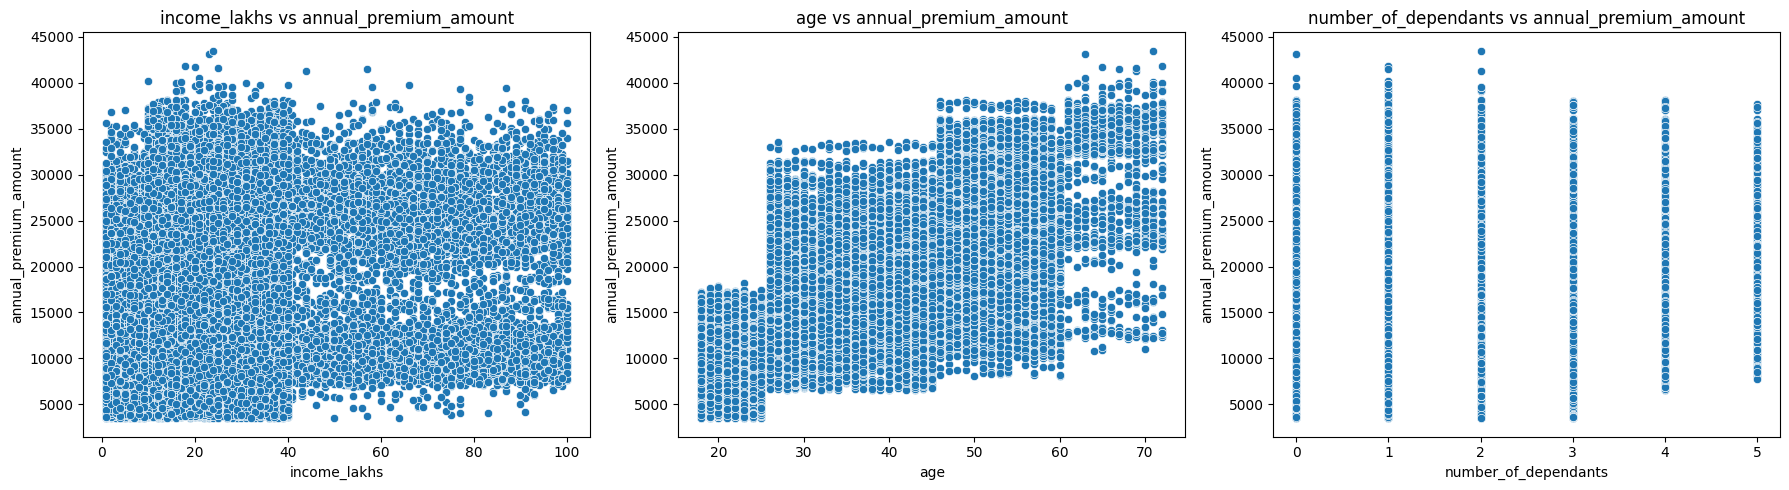

In [312]:
features = ['income_lakhs', 'age', 'number_of_dependants']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(features):
    sns.scatterplot(
        data=df1,
        x=col,
        y='annual_premium_amount',
        ax=axes[i]
    )
    axes[i].set_title(f'{col} vs annual_premium_amount')

plt.tight_layout()
plt.show()
#from the other 2 plots we dont see a clear relationship as seen for age

### Analysis for categorical columns

In [313]:
cat_col = df1.select_dtypes(include=['object', 'string']).columns.tolist()
cat_col

['gender',
 'region',
 'marital_status',
 'bmi_category',
 'smoking_status',
 'employment_status',
 'income_level',
 'medical_history',
 'insurance_plan']

In [314]:
#for each col, we need its unique values
for col in cat_col:
    print(f"\n{col}:")
    print(", ".join(map(str, df1[col].dropna().unique())))


gender:
Male, Female

region:
Northwest, Southeast, Northeast, Southwest

marital_status:
Unmarried, Married

bmi_category:
Normal, Obesity, Overweight, Underweight

smoking_status:
No Smoking, Regular, Occasional, Smoking=0, Does Not Smoke, Not Smoking

employment_status:
Salaried, Self-Employed, Freelancer

income_level:
<10L, 10L - 25L, > 40L, 25L - 40L

medical_history:
Diabetes, High blood pressure, No Disease, Diabetes & High blood pressure, Thyroid, Heart disease, High blood pressure & Heart disease, Diabetes & Thyroid, Diabetes & Heart disease

insurance_plan:
Bronze, Silver, Gold


In [315]:
#in smoking- no smoking, smoking=0, does not smoke, not smoking all accounts to the same thing
df1['smoking_status'] = df1['smoking_status'].replace({
    'No Smoking': 'Non-Smoker',
    'Smoking=0': 'Non-Smoker',
    'Does Not Smoke': 'Non-Smoker',
    'Not Smoking': 'Non-Smoker'
})

### univeriate analysis on categorical columns

In [316]:
pct_count= df1['gender'].value_counts(normalize=True)

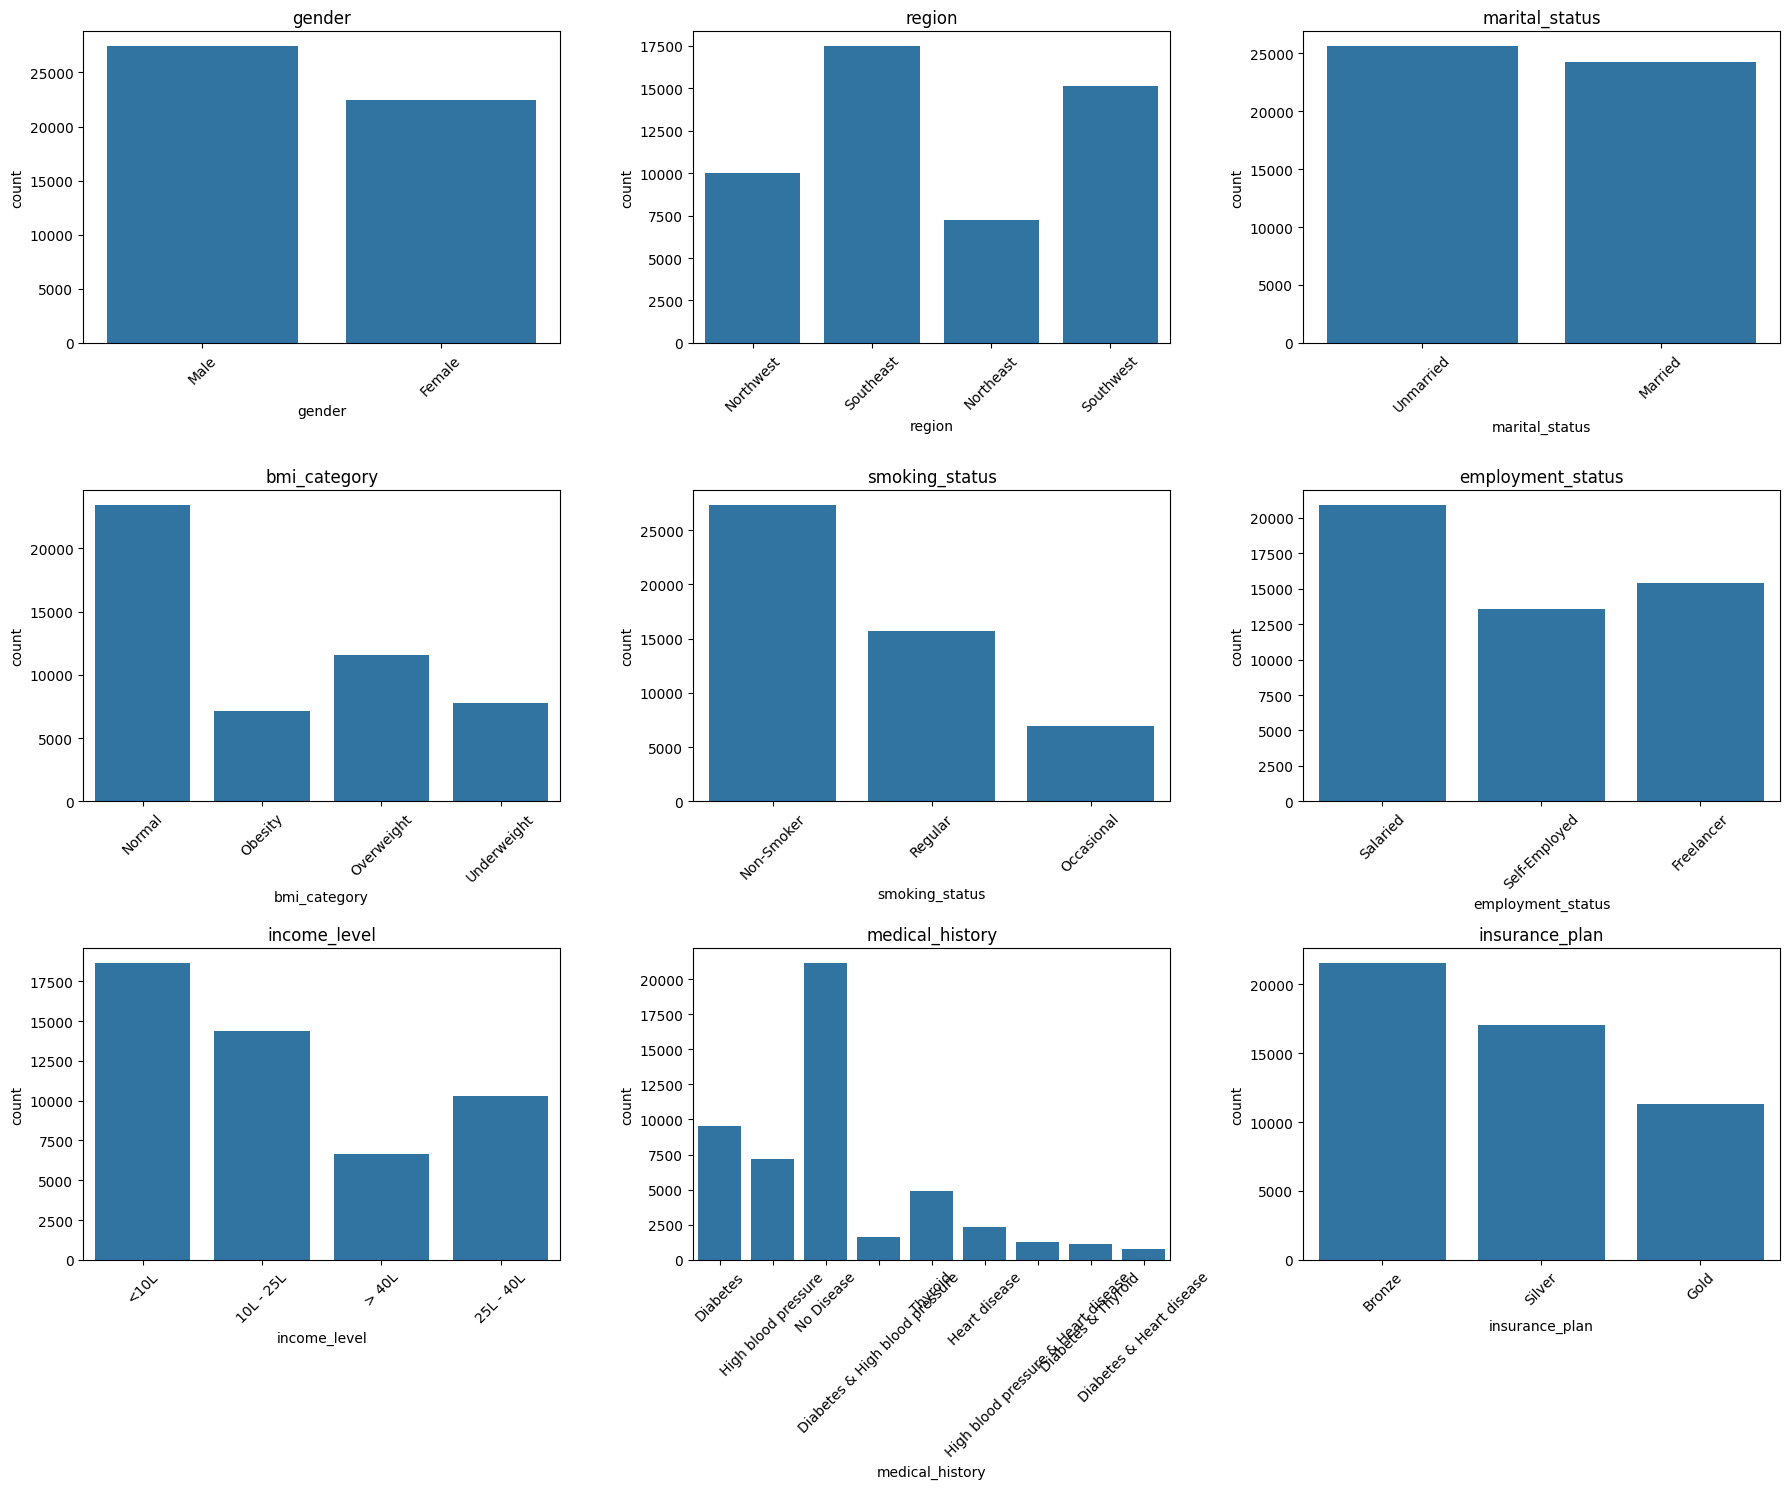

In [317]:
import math
n_cols = 3
n_rows = math.ceil(len(cat_col) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_col):
    sns.countplot(data=df1, x=col, ax=axes[i])

    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [318]:
# Male customers slightly outnumber female customers.

# Southeast is the most represented region, while Northeast has the fewest customers.

# Unmarried and Married customers are nearly equally distributed.

# Most customers fall under the Normal BMI category.
# Obesity is the second largest BMI group.

# Non-Smokers dominate the dataset.
# Occasional smokers form the smallest smoking group.

# Salaried individuals represent the largest employment segment.

# Most customers earn less than 10L annually.
# The >40L income group is the smallest.

# A majority of customers report no medical conditions.
# Multiple-disease combinations are relatively rare.

# Bronze insurance plans are the most popular,
# while Gold plans are the least chosen.

### Which income group prefers which plan

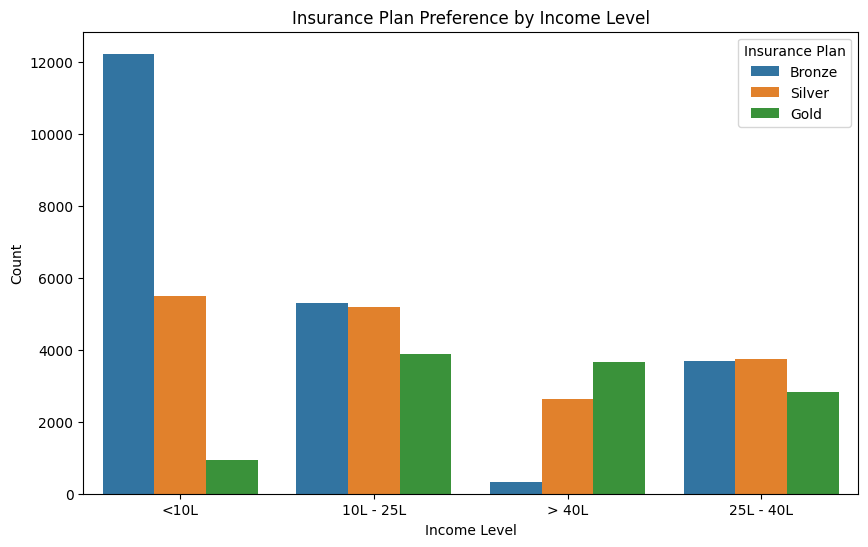

In [319]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df1,
    x='income_level',
    hue='insurance_plan'
)

plt.title('Insurance Plan Preference by Income Level')
plt.xlabel('Income Level')
plt.ylabel('Count')
plt.legend(title='Insurance Plan')
plt.show()

In [320]:
pd.crosstab(
    df1['income_level'],
    df1['insurance_plan'],
    margins=True
)

insurance_plan,Bronze,Gold,Silver,All
income_level,,,,
10L - 25L,5307,3880,5182,14369
25L - 40L,3683,2840,3750,10273
<10L,12226,931,5486,18643
> 40L,329,3653,2641,6623
All,21545,11304,17059,49908


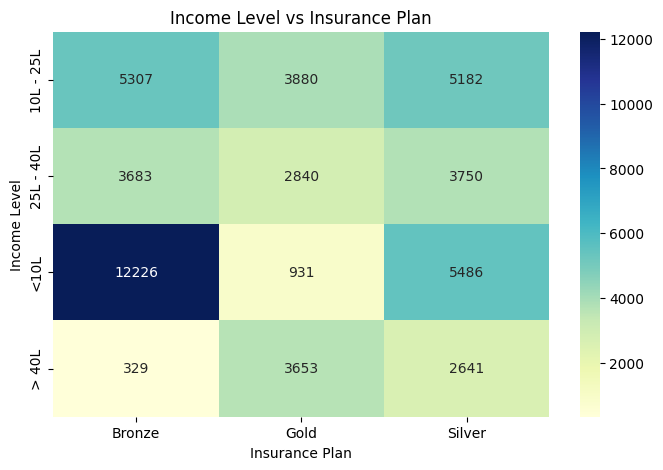

In [321]:
cross_tab = pd.crosstab(
    df1['income_level'],
    df1['insurance_plan']
)

plt.figure(figsize=(8, 5))
sns.heatmap(
    cross_tab,
    annot=True,
    fmt='d',
    cmap='YlGnBu'
)

plt.title('Income Level vs Insurance Plan')
plt.xlabel('Insurance Plan')
plt.ylabel('Income Level')
plt.show()

### Feature Engineering


In [322]:
#now we need to convert the disease names into numbers so that the model can understrand
#each disease can be converted to numbers based on a spectfic risk score
df1.medical_history.unique()

<StringArray>
[                           'Diabetes',                 'High blood pressure',
                          'No Disease',      'Diabetes & High blood pressure',
                             'Thyroid',                       'Heart disease',
 'High blood pressure & Heart disease',                  'Diabetes & Thyroid',
            'Diabetes & Heart disease']
Length: 9, dtype: str

In [323]:
# Risk score mapping
risk_map = {
    'Diabetes': 6,
    'Heart disease': 8,
    'High blood pressure': 6,
    'Thyroid': 5,
    'No Disease': 0,
    'None': 0
}

# Split medical history into two disease columns
df1[['disease_1', 'disease_2']] = (
    df1['medical_history']
    .str.split(' & ', expand=True)
)

# Fill missing second disease
df1['disease_2'] = df1['disease_2'].fillna('None')

# Create total risk score
df1['total_risk_score'] = (
    df1['disease_1'].map(risk_map) +
    df1['disease_2'].map(risk_map)
)

# Check results
df1[['medical_history', 'disease_1', 'disease_2', 'total_risk_score']].head(10)

,medical_history,disease_1,disease_2,total_risk_score
0,Diabetes,Diabetes,None,6
1,Diabetes,Diabetes,None,6
2,High blood pressure,High blood pressure,None,6
3,No Disease,No Disease,None,0
4,High blood pressure,High blood pressure,None,6
5,Diabetes,Diabetes,None,6
6,Diabetes & High blood pressure,Diabetes,High blood pressure,12
7,Thyroid,Thyroid,None,5
8,No Disease,No Disease,None,0
9,No Disease,No Disease,None,0


In [324]:
df1.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease_1,disease_2,total_risk_score
0,26,Male,Northwest,Unmarried,0,Normal,Non-Smoker,Salaried,<10L,6,Diabetes,Bronze,9053,Diabetes,None,6
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,Diabetes,None,6
2,49,Female,Northeast,Married,2,Normal,Non-Smoker,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164,High blood pressure,None,6
3,30,Female,Southeast,Married,3,Normal,Non-Smoker,Salaried,> 40L,77,No Disease,Gold,20303,No Disease,None,0
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,High blood pressure,None,6


In [325]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df1['normalized_risk_score'] = scaler.fit_transform(
    df1[['total_risk_score']]
)
df1.sample(5)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease_1,disease_2,total_risk_score,normalized_risk_score
9672,44,Male,Northeast,Married,4,Underweight,Regular,Salaried,> 40L,49,Heart disease,Silver,22782,Heart disease,None,8,0.571429
33008,57,Female,Southwest,Married,3,Overweight,Non-Smoker,Salaried,10L - 25L,10,High blood pressure,Gold,28163,High blood pressure,None,6,0.428571
18684,54,Female,Southeast,Married,2,Normal,Non-Smoker,Self-Employed,10L - 25L,19,High blood pressure,Gold,26686,High blood pressure,None,6,0.428571
9808,20,Male,Southeast,Unmarried,1,Normal,Non-Smoker,Freelancer,25L - 40L,35,No Disease,Silver,9454,No Disease,None,0,0.000000
36781,33,Male,Southeast,Married,5,Obesity,Non-Smoker,Freelancer,> 40L,93,High blood pressure & Heart disease,Gold,30556,High blood pressure,Heart disease,14,1.000000


In [340]:
#for insurance plan, use lable encoding
df1['insurance_plan']=df['Insurance_Plan'].map({'Bronze':1, 'Silver':2, 'Gold':3})
df1.insurance_plan.unique()


array([1, 2, 3])

In [341]:
df1.head()

,age,number_of_dependants,bmi_category,income_level,income_lakhs,medical_history,annual_premium_amount,disease_1,disease_2,total_risk_score,...,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed,insurance_plan
0,26,0,Normal,<10L,6,Diabetes,9053,Diabetes,None,6,...,1,1,0,0,1,0,0,1,0,1
1,29,2,Obesity,<10L,6,Diabetes,16339,Diabetes,None,6,...,0,0,1,0,0,0,1,1,0,1
2,49,2,Normal,10L - 25L,20,High blood pressure,18164,High blood pressure,None,6,...,0,0,0,0,0,0,0,0,1,2
3,30,3,Normal,> 40L,77,No Disease,20303,No Disease,None,0,...,0,0,1,0,0,0,0,1,0,3
4,18,0,Overweight,> 40L,99,High blood pressure,13365,High blood pressure,None,6,...,1,0,0,0,1,0,1,0,1,2


In [ ]:
# for the nominal columns, use one-hot encoding
nominal_cols = [
    'gender',
    'region',
    'marital_status',
    'smoking_status',
    'employment_status',
     'insurance_plan'
]

df1 = pd.get_dummies(
    df1,
    columns=nominal_cols,
    drop_first=True,  # avoids dummy variable trap
    dtype=int
)

In [343]:
df1.head()

,age,number_of_dependants,bmi_category,income_level,income_lakhs,medical_history,annual_premium_amount,disease_1,disease_2,total_risk_score,...,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed,insurance_plan
0,26,0,Normal,<10L,6,Diabetes,9053,Diabetes,None,6,...,1,1,0,0,1,0,0,1,0,1
1,29,2,Obesity,<10L,6,Diabetes,16339,Diabetes,None,6,...,0,0,1,0,0,0,1,1,0,1
2,49,2,Normal,10L - 25L,20,High blood pressure,18164,High blood pressure,None,6,...,0,0,0,0,0,0,0,0,1,2
3,30,3,Normal,> 40L,77,No Disease,20303,No Disease,None,0,...,0,0,1,0,0,0,0,1,0,3
4,18,0,Overweight,> 40L,99,High blood pressure,13365,High blood pressure,None,6,...,1,0,0,0,1,0,1,0,1,2


In [ ]:
print(df1.columns.tolist())

['age', 'number_of_dependants', 'bmi_category', 'income_level', 'income_lakhs', 'medical_history', 'annual_premium_amount', 'disease_1', 'disease_2', 'total_risk_score', 'normalized_risk_score', 'gender_Male', 'region_Northwest', 'region_Southeast', 'region_Southwest', 'marital_status_Unmarried', 'smoking_status_Occasional', 'smoking_status_Regular', 'employment_status_Salaried', 'employment_status_Self-Employed', 'insurance_plan_Gold', 'insurance_plan_Silver']


In [ ]:
df2= df1.drop(['medical_history', 'disease_1','disease_2', 'total_risk_score'], axis=1)

In [ ]:
df2['normalized_risk_score'].head()

0    0.428571
1    0.428571
2    0.428571
3    0.000000
4    0.428571
Name: normalized_risk_score, dtype: float64

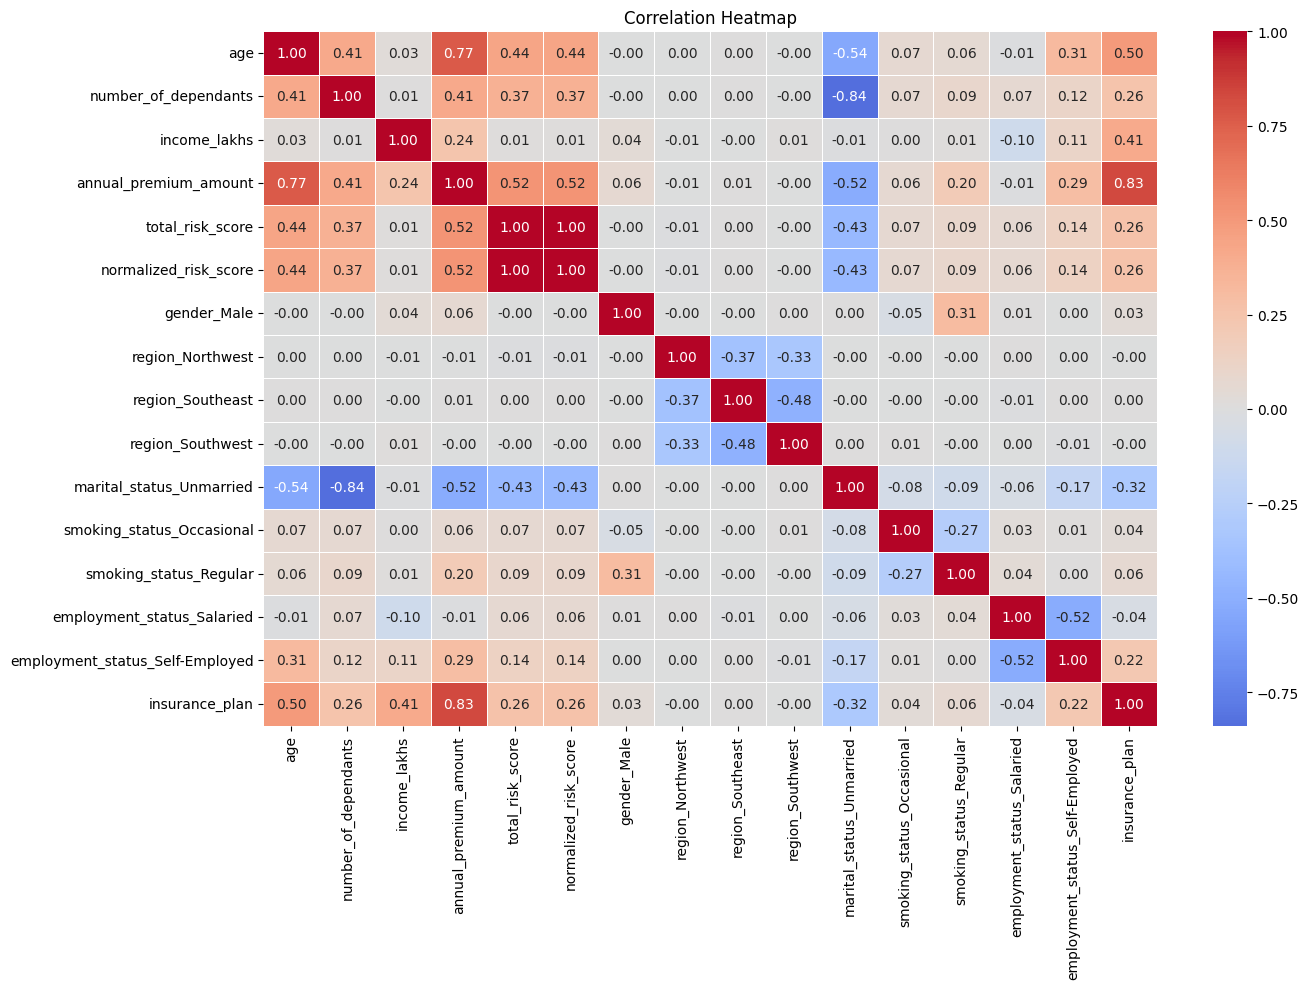

In [ ]:
plt.figure(figsize=(14, 10))

corr_matrix = df1.corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

### VIF calculation

In [346]:

df2['income_level'] = df2['income_level'].map({'<10L':1, '10L - 25L': 2, '25L - 40L':3, '> 40L':4})


In [ ]:
df2= df2.drop(['bmi_category_Obesity', 'bmi_category_Overweight',
       'bmi_category_Underweight', 'bmi_category_25L - 40L',
       'bmi_category_<10L', 'bmi_category_> 40L',
       'bmi_category_Diabetes & Heart disease',
       'bmi_category_Diabetes & High blood pressure',
       'bmi_category_Diabetes & Thyroid', 'bmi_category_Heart disease',
       'bmi_category_High blood pressure',
       'bmi_category_High blood pressure & Heart disease',
       'bmi_category_No Disease', 'bmi_category_Thyroid',
       'bmi_category_Heart disease', 'bmi_category_High blood pressure',
       'bmi_category_No Disease', 'bmi_category_Thyroid',
       'bmi_category_High blood pressure', 'bmi_category_None',
       'bmi_category_Thyroid'], axis=1)

In [347]:
df2.columns

Index(['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount',
       'normalized_risk_score', 'gender_Male', 'region_Northwest',
       'region_Southeast', 'region_Southwest', 'marital_status_Unmarried',
       'smoking_status_Occasional', 'smoking_status_Regular',
       'employment_status_Salaried', 'employment_status_Self-Employed',
       'insurance_plan', 'income_level', 'bmi_category_Obesity',
       'bmi_category_Overweight', 'bmi_category_Underweight'],
      dtype='str')

In [348]:
df2['bmi_category'] =df['BMI_Category']
df2.head()

,age,number_of_dependants,income_lakhs,annual_premium_amount,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed,insurance_plan,income_level,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,bmi_category
0,0.148148,0,6,9053,0.428571,1,1,0,0,1,0,0,1,0,1,NaN,0,0,0,Normal
1,0.203704,2,6,16339,0.428571,0,0,1,0,0,0,1,1,0,1,NaN,1,0,0,Obesity
2,0.574074,2,20,18164,0.428571,0,0,0,0,0,0,0,0,1,2,NaN,0,0,0,Normal
3,0.222222,3,77,20303,0.000000,0,0,1,0,0,0,0,1,0,3,NaN,0,0,0,Normal
4,0.000000,0,99,13365,0.428571,1,0,0,0,1,0,1,0,1,2,NaN,0,1,0,Overweight


In [ ]:
df2 = pd.get_dummies(df2, columns=['bmi_category'], drop_first=True,dtype=int)
df2.sample(5)

In [ ]:
df2.sample(5)

,age,number_of_dependants,income_lakhs,annual_premium_amount,total_risk_score,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed,insurance_plan,income_level,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight
35173,19,0,16,7802,0,0.000000,1,1,0,0,1,0,0,1,0,2,2.0,0,0,0
8896,18,1,62,10658,0,0.000000,1,0,1,0,1,0,1,0,0,2,4.0,0,0,1
29494,54,5,25,29349,6,0.428571,0,0,0,1,0,0,1,0,0,3,2.0,0,0,0
7793,43,4,21,15594,6,0.428571,0,0,0,1,0,0,0,0,1,2,2.0,0,0,0
11867,20,0,8,8349,0,0.000000,1,0,0,0,1,0,0,1,0,1,1.0,0,0,0


In [ ]:
df2=df2.dropna()

In [ ]:
df2=df2.drop('total_risk_score', axis=1)

In [ ]:
#1st drop the target column
x= df2.drop('annual_premium_amount', axis='columns')
y= df2.annual_premium_amount

In [ ]:
cols_to_scale= ['age', 'number_of_dependants', 'income_level','income_lakhs', 'insurance_plan']
x[cols_to_scale]= scaler.fit_transform(x[cols_to_scale])
x.sample(10)


,age,number_of_dependants,income_lakhs,total_risk_score,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed,insurance_plan,income_level,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight
5425,0.000000,0.625,0.040404,0,0.000000,1,0,1,0,1,0,0,1,0,0.0,0.000000,0,0,0
1030,0.703704,0.375,0.343434,5,0.357143,1,0,1,0,1,0,1,0,0,1.0,0.666667,0,1,0
17664,0.166667,0.750,0.141414,11,0.785714,1,0,1,0,0,0,0,0,0,0.5,0.333333,0,1,0
12018,0.129630,0.375,0.060606,0,0.000000,0,0,1,0,1,0,0,1,0,0.0,0.000000,0,0,0
21010,0.592593,0.750,0.050505,8,0.571429,1,0,1,0,0,0,1,0,0,0.5,0.000000,1,0,0
30902,0.648148,0.750,0.181818,6,0.428571,0,1,0,0,0,0,0,0,1,1.0,0.333333,0,1,0
35185,0.685185,0.750,0.232323,8,0.571429,0,0,0,0,0,0,1,1,0,1.0,0.333333,1,0,0
12776,0.685185,0.750,0.030303,5,0.357143,0,0,1,0,0,0,1,1,0,0.5,0.000000,0,1,0
40462,0.037037,0.375,0.060606,0,0.000000,0,0,1,0,1,0,0,0,1,0.0,0.000000,0,0,0
48044,0.129630,0.375,0.676768,0,0.000000,0,1,0,0,1,0,0,0,0,0.5,1.000000,0,0,0


In [ ]:
x.columns

Index(['age', 'number_of_dependants', 'income_lakhs', 'total_risk_score',
       'normalized_risk_score', 'gender_Male', 'region_Northwest',
       'region_Southeast', 'region_Southwest', 'marital_status_Unmarried',
       'smoking_status_Occasional', 'smoking_status_Regular',
       'employment_status_Salaried', 'employment_status_Self-Employed',
       'insurance_plan', 'income_level', 'bmi_category_Obesity',
       'bmi_category_Overweight', 'bmi_category_Underweight'],
      dtype='str')

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df['Column'] = data.columns
    vif_df['VIF'] = [variance_inflation_factor(data.values,i) for i in range(data.shape[1])]
    return vif_df
    

In [ ]:
calculate_vif(x)

C:\Users\KIIT\AppData\Roaming\Python\Python314\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Column,VIF
0,age,12.098894
1,number_of_dependants,5.353852
2,income_lakhs,10.863677
3,total_risk_score,inf
4,normalized_risk_score,inf
5,gender_Male,2.452374
6,region_Northwest,2.191510
7,region_Southeast,3.077970
8,region_Southwest,2.801672
9,marital_status_Unmarried,4.059870


In [330]:
calculate_vif(x.drop('income_level', axis="columns"))
#drop the one having highest vif

,Column,VIF
0,age,4.797403
1,number_of_dependants,4.780351
2,income_lakhs,2.649323
3,normalized_risk_score,2.699596
4,gender_Male,2.418499
5,region_Northwest,2.117596
6,region_Southeast,2.952574
7,region_Southwest,2.693049
8,marital_status_Unmarried,3.698951
9,smoking_status_Occasional,1.272810


In [ ]:
x_reduced = x.drop('income_level', axis="columns")

### Model Training and Fine Tuning

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_reduced, y, test_size=0.30, random_state=10)

# shape of the X_train, X_test, y_train, y_test features
print("x train: ",x_train.shape)
print("x test: ",x_test.shape)
print("y train: ",y_train.shape)
print("y test: ",y_test.shape)

x train:  (34943, 17)
x test:  (14976, 17)
y train:  (34943,)
y test:  (14976,)


### Linear regression model

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split

In [ ]:

model_lr = LinearRegression()
model_lr.fit(x_train, y_train)
test_score = model_lr.score(x_test, y_test)
train_score = model_lr.score(x_train, y_train)
train_score, test_score

(0.928141534991988, 0.928253050132875)

In [ ]:
model_lr.intercept_

np.float64(-5300.508290002588)

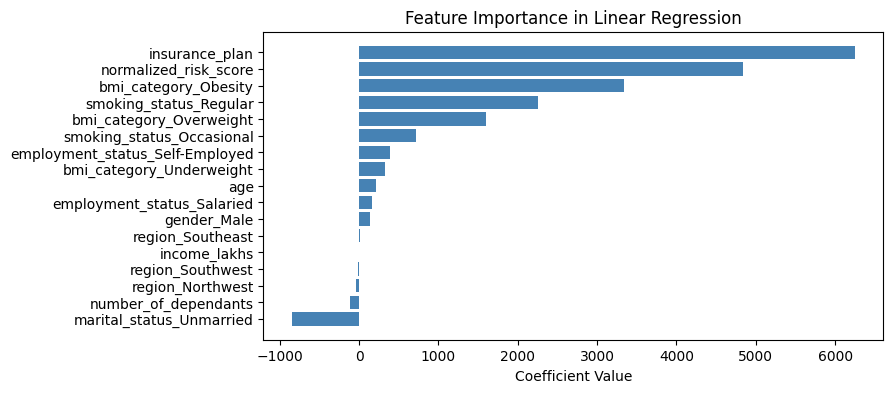

In [ ]:
feature_importance = model_lr.coef_

# Create a DataFrame for easier handling
coef_df = pd.DataFrame(feature_importance, index=x_train.columns, columns=['Coefficients'])

# Sort the coefficients for better visualization
coef_df = coef_df.sort_values(by='Coefficients', ascending=True)

# Plotting
plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in Linear Regression')
plt.show()

In [ ]:
coef_df

,Coefficients
marital_status_Unmarried,-849.708824
number_of_dependants,-111.397835
region_Northwest,-40.246075
region_Southwest,-16.606724
income_lakhs,-4.464759
region_Southeast,13.991285
gender_Male,133.050383
employment_status_Salaried,167.434258
age,209.518920
bmi_category_Underweight,320.760694


### Ridge Regression

In [ ]:
model_rg = Ridge(alpha=10)
model_rg.fit(x_train, y_train)
test_score = model_rg.score(x_test, y_test)
train_score = model_rg.score(x_train, y_train)
train_score, test_score

(0.9281408267097058, 0.9282518348937652)

In [ ]:
y_pred = model_rg.predict(x_test)

mse_lr = mean_squared_error(y_test, y_pred)
rmse_lr = np.sqrt(mse_lr)
print("Ridge Regression ==> MSE: ", mse_lr, "RMSE: ", rmse_lr)

Ridge Regression ==> MSE:  5086579.497670386 RMSE:  2255.344651637613


### XGBoost Regression

In [ ]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor(n_estimators=20, max_depth=3)
model_xgb.fit(x_train, y_train)
model_xgb.score(x_test, y_test)

0.9778581857681274

In [ ]:
y_pred = model_xgb.predict(x_test)

mse_lr = mean_squared_error(y_test, y_pred)
rmse_lr = np.sqrt(mse_lr)
print("XGBoost Regression ==> MSE: ", mse_lr, "RMSE: ", rmse_lr)

XGBoost Regression ==> MSE:  1569742.25 RMSE:  1252.893550945171


In [ ]:
#now for model finetuning we wiil be usnig randomizedSearchCV as the dataset is large
model_xgb = XGBRegressor()
param_grid = {
    'n_estimators': [20, 40, 50],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
}
random_search = RandomizedSearchCV(model_xgb, param_grid, n_iter=10, cv=3, scoring='r2', random_state=42, n_jobs=-1)
random_search.fit(x_train, y_train)
random_search.best_score_

np.float64(0.9810589750607809)

In [ ]:
random_search.best_params_

In [ ]:
best_model_= random_search.best_estimator_#this provides the model having the most accuracy based on all the given parameters

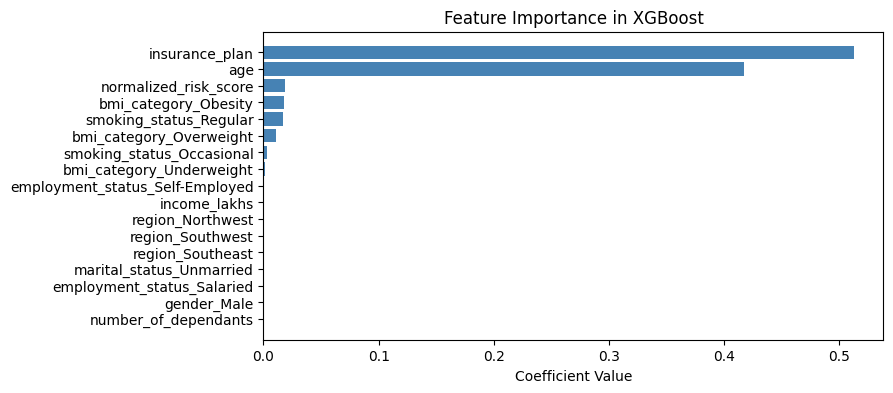

In [ ]:
feature_importance = best_model_.feature_importances_

# Create a DataFrame for easier handling
coef_df = pd.DataFrame(feature_importance, index=x_train.columns, columns=['Coefficients'])

# Sort the coefficients for better visualization
coef_df = coef_df.sort_values(by='Coefficients', ascending=True)

# Plotting
plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in XGBoost')
plt.show()

### Error Analysis


In [ ]:
x_test['age'] = df1.loc[x_test.index, 'age']
#I forgot to scale it earlier which didn't cause much error luckily. later I dont need to do reverse scaling

In [ ]:
y_pred = best_model_.predict(x_test)
residuals = y_pred - y_test # difference b/w actual and prediction
residuals_pct = (residuals / y_test) * 100

results_df = pd.DataFrame({
    'actual': y_test, 
    'predicted': y_pred, 
    'diff': residuals, 
    'diff_pct': residuals_pct
})
results_df.head()

,actual,predicted,diff,diff_pct
11055,14409,14017.422852,-391.577148,-2.717587
28387,4921,6994.966797,2073.966797,42.145231
33307,7846,9865.038086,2019.038086,25.733343
13942,5361,7645.415039,2284.415039,42.611734
47257,7459,6623.278320,-835.721680,-11.204205


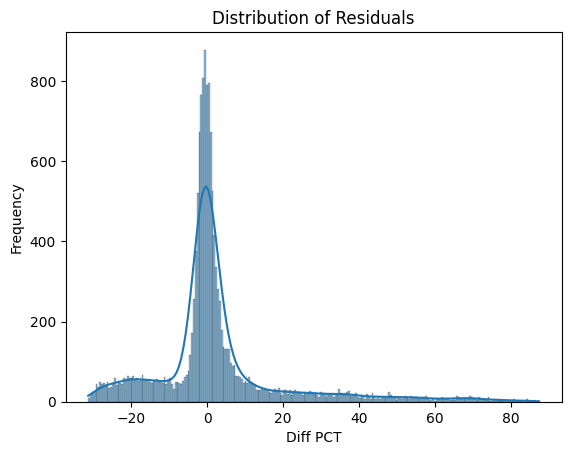

In [ ]:
sns.histplot(results_df['diff_pct'], kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Diff PCT')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# 1. Strong center peak near 0 shows model is accurate for most data points
# 2. Right-skewed distribution indicates a tendency to under-predict premiums
# 3. Long tail up to +80 shows large positive outliers/under-predictions
# 4. Non-normal residual distribution suggests missed non-linear relationships
error_threshold= 10
extreme_results_df = results_df[np.abs(results_df.diff_pct)>error_threshold]

In [ ]:
extreme_errors_pct = extreme_results_df.shape[0]*100/x_test.shape[0]
extreme_errors_pct
#error result*100/ test dataset i.e. percentage of extreme error

29.82104700854701

In [ ]:
extreme_results_df[abs(extreme_results_df.diff_pct)>50].sort_values("diff_pct",ascending=False)

,actual,predicted,diff,diff_pct
36269,3501,6564.852539,3063.852539,87.513640
18922,3502,6564.852539,3062.852539,87.460095
18564,3523,6571.510254,3048.510254,86.531656
42342,3521,6564.852539,3043.852539,86.448524
48801,3516,6542.228516,3026.228516,86.070208
...,...,...,...,...
49418,5061,7602.479004,2541.479004,50.216933
16171,5310,7974.791504,2664.791504,50.184397
30639,4678,7023.352539,2345.352539,50.135796
31484,4435,6657.531250,2222.531250,50.113444


### highest error margin is 87% and we have 537 rows having more than 50 error margin. so this model clearly has a problem

In [ ]:
# Select the rows from X_test corresponding to the observations
# with the largest prediction errors (identified in extreme_results_df).
# This helps analyze the feature values of cases where the model
# performed particularly poorly.
extreme_errors_df = x_test.loc[extreme_results_df.index]

# Display the first 2 records of these high-error observations
extreme_errors_df.head(2)

,age,number_of_dependants,income_lakhs,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed,insurance_plan,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight
28387,19,0,15,0.428571,0,0,1,0,1,0,0,0,0,1,0,0,0
33307,24,1,14,0.000000,1,0,0,1,1,0,0,1,0,2,0,0,0


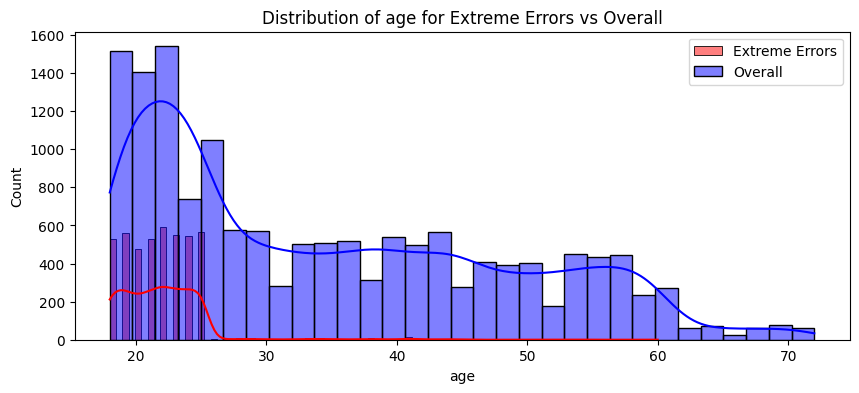

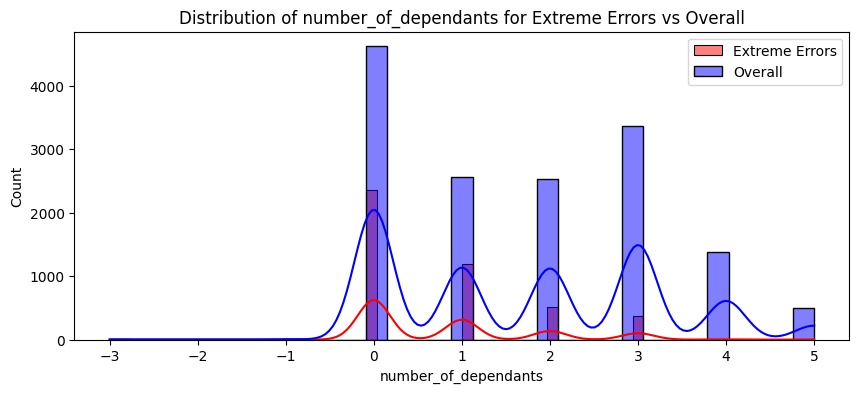

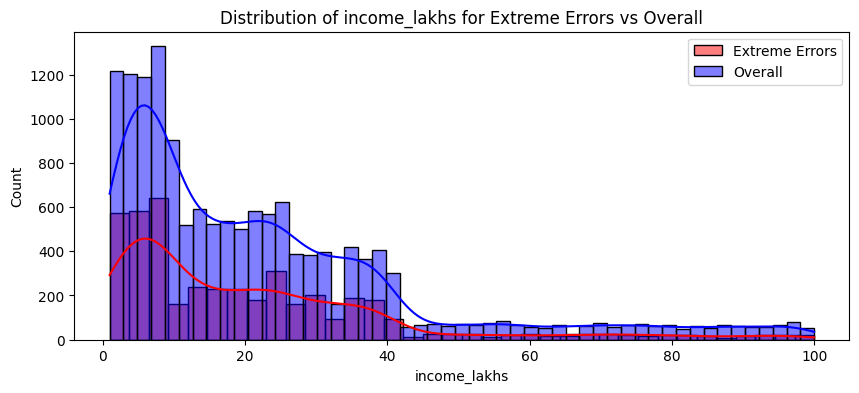

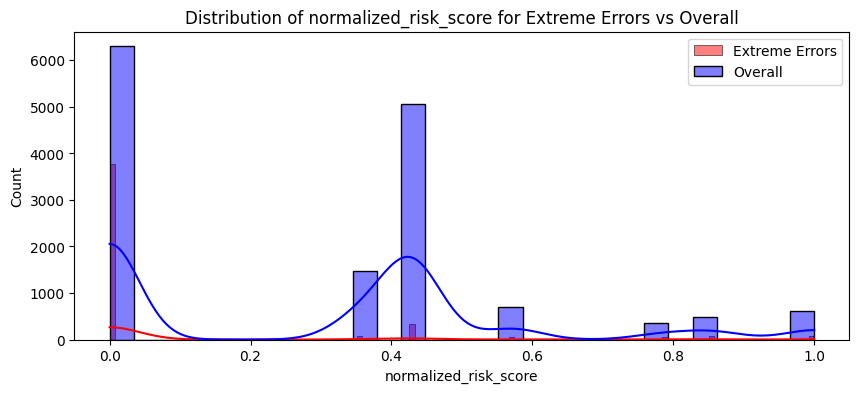

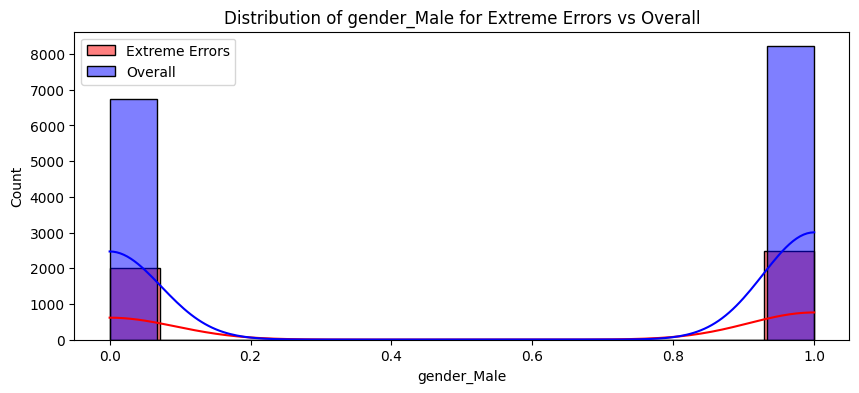

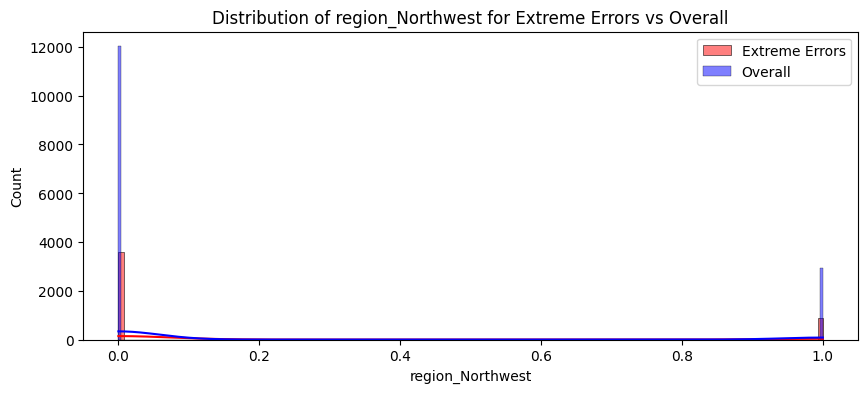

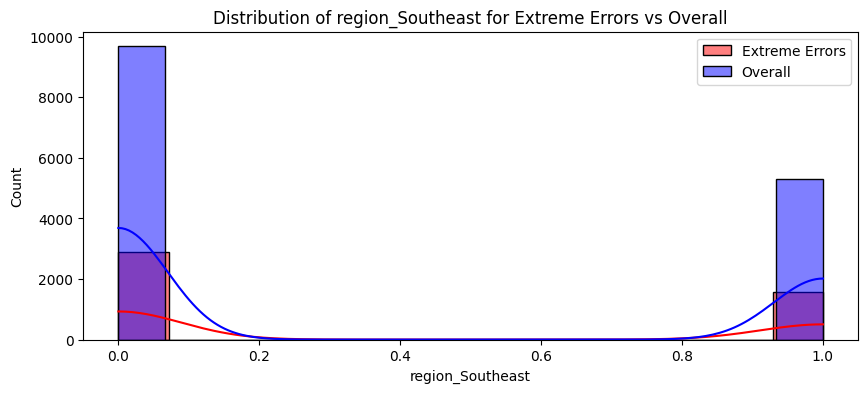

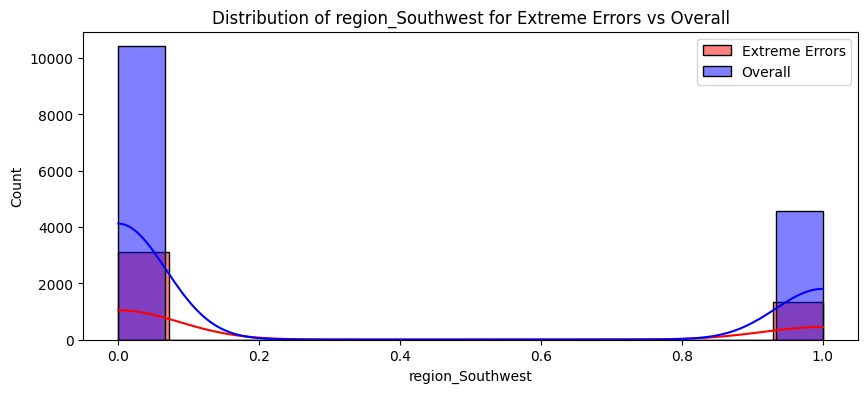

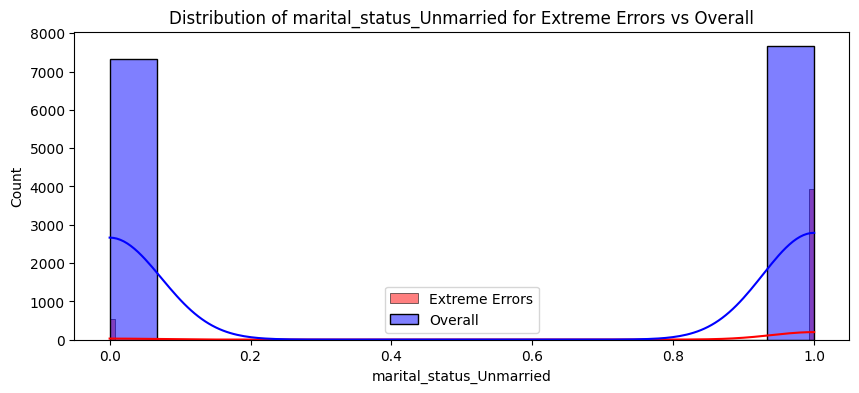

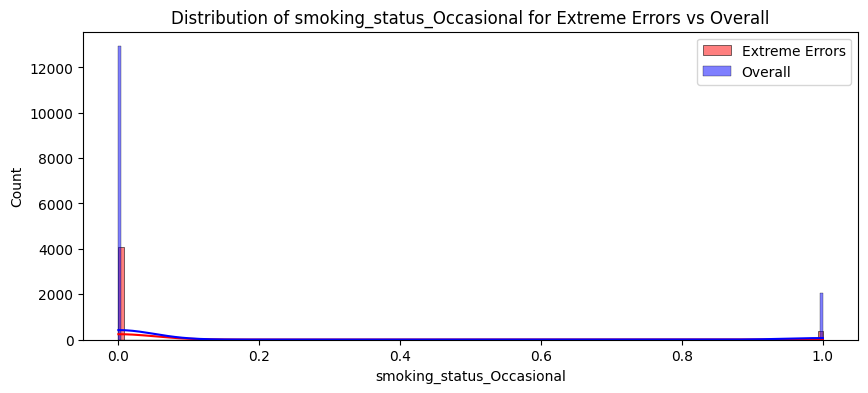

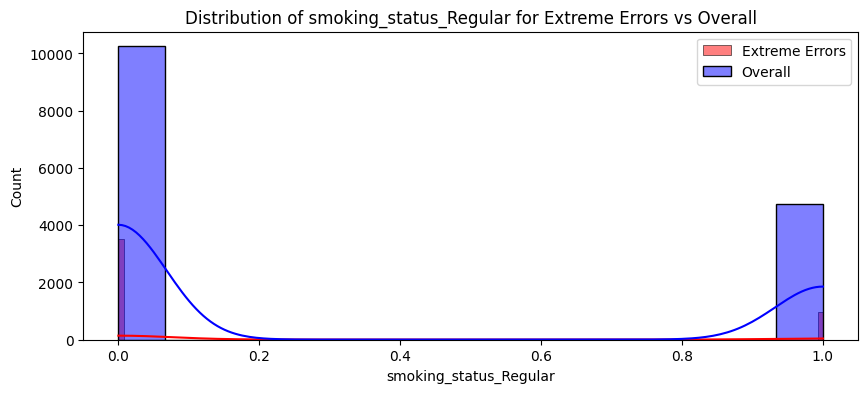

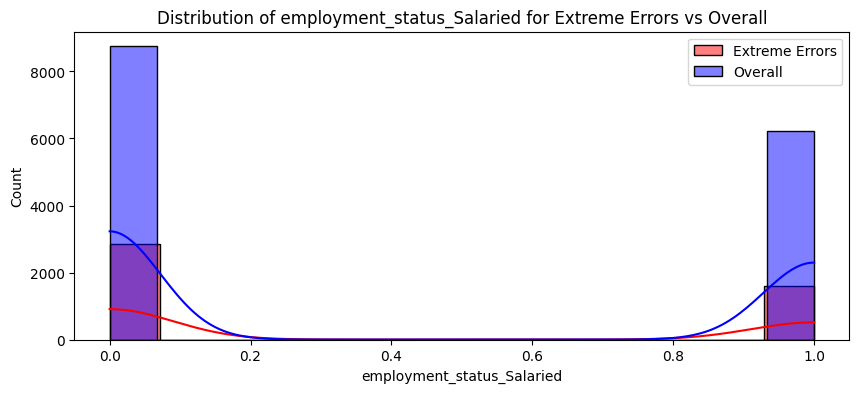

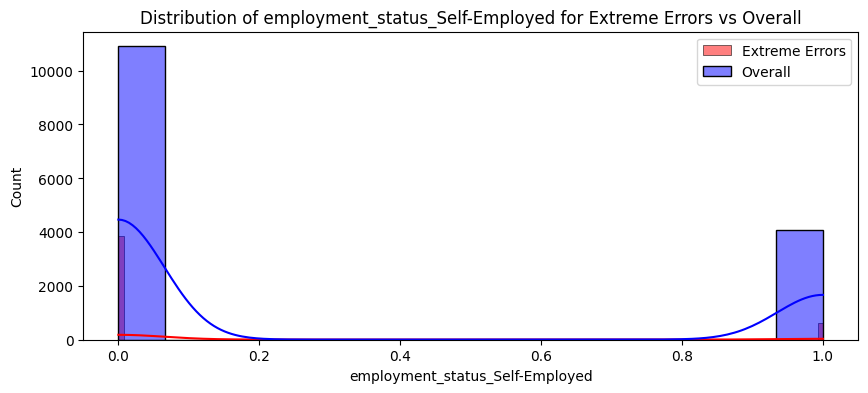

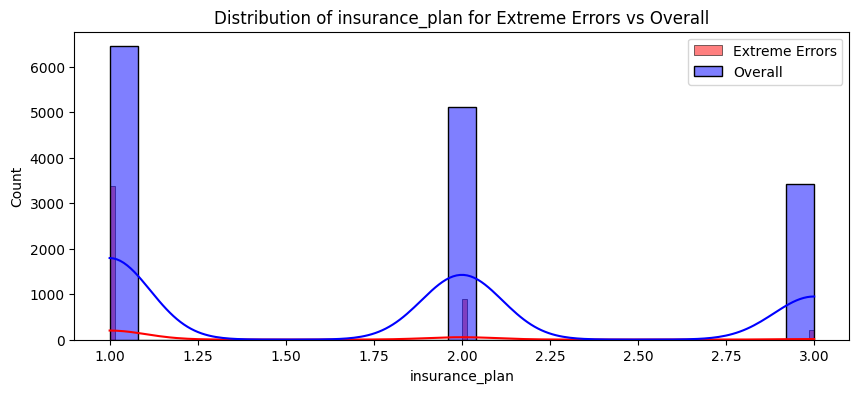

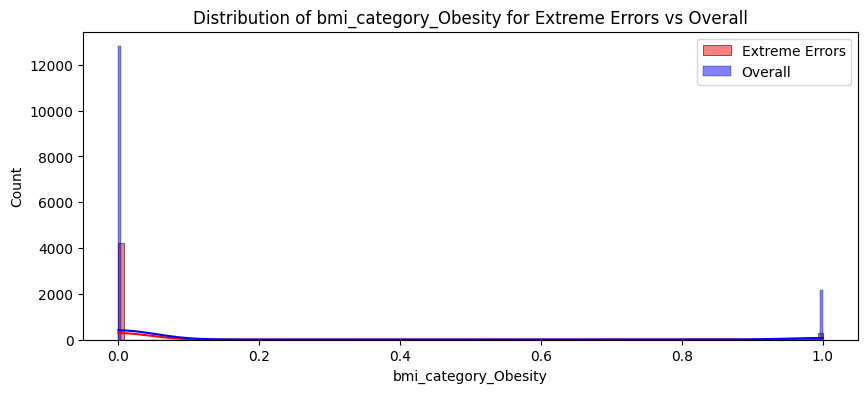

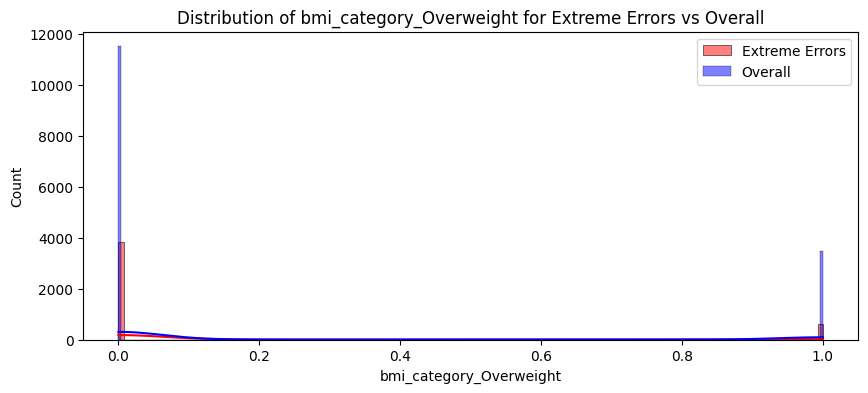

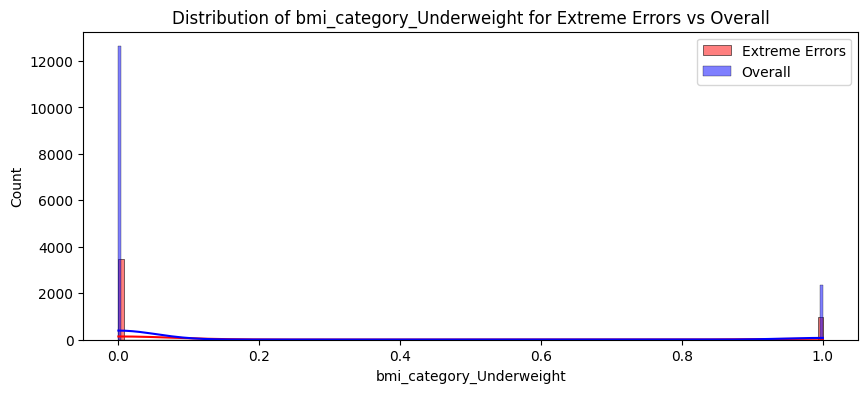

In [ ]:
#There will be about 549 customers whom we will overcharge or underchage by more than 50%
for feature in x_test.columns:
    plt.figure(figsize=(10, 4))
    sns.histplot(extreme_errors_df[feature], color='red', label='Extreme Errors', kde=True)
    sns.histplot(x_test[feature], color='blue', label='Overall', alpha=0.5, kde=True)
    plt.legend()
    plt.title(f'Distribution of {feature} for Extreme Errors vs Overall')
    plt.show()

### In each plot we can see the error and test have similar position though different intensity. but for age we can see there is a major problem

### Reverse Scaling

In [ ]:
extreme_errors_df['income_level']=-1
#I forgot to scale age previously. I have the original values now. So I wont reverse scale it

In [ ]:
#df2['age'] = scaler.fit_transform(df2[['age']])

In [ ]:
df_reversed = extreme_errors_df.copy()

df_reversed[cols_to_scale] = scaler.inverse_transform(
    extreme_errors_df[cols_to_scale]
)

df_reversed.head()
#previously I have done reverse scaling without knowing that age was not scaled. So I have reversed it again to get the original

,age,number_of_dependants,income_lakhs,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed,insurance_plan,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,income_level
28387,19.0,0.0,15.0,0.428571,0,0,1,0,1,0,0,0,0,1.0,0,0,0,-1.0
33307,24.0,1.0,14.0,0.000000,1,0,0,1,1,0,0,1,0,2.0,0,0,0,-1.0
13942,23.0,1.0,9.0,0.857143,1,0,1,0,1,0,0,0,1,1.0,0,0,1,-1.0
47257,19.0,1.0,21.0,0.000000,0,1,0,0,1,0,0,0,0,1.0,0,0,1,-1.0
18713,21.0,0.0,5.0,0.000000,0,1,0,0,1,1,0,0,0,1.0,0,1,0,-1.0


<Axes: xlabel='age', ylabel='Count'>

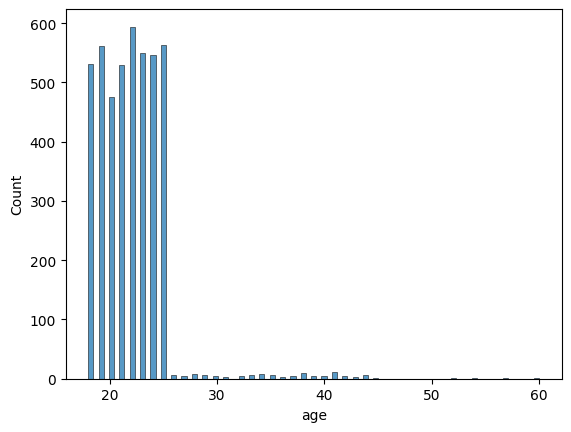

In [ ]:
sns.histplot(df_reversed.age)
# if your age was scaled earlier then use the code present in codebasics module

This shows that majority of the extreme errors are coming from young age group (i.e. <25 years of age). We need to may be build a separate model for this segment